# M3DSynth — Dataset Visualizer

Notebook for visually exploring samples from the M3DSynth dataset.

| Section | Content |
|---------|--------|
| **Setup** | Imports, paths, loading helpers |
| **2D — single sample** | Slice at `coord_z` for all 4 modalities + mask overlay |
| **2D — multi-sample grid** | N random nodules in a single compact figure |
| **2D — difference heatmap** | Real vs fake with residual map |
| **2D interactive** | Z slider to scroll through a volume slice by slice |
| **3D — orthogonal views** | Axial / Coronal / Sagittal for all 4 modalities |
| **3D — MIP** | Maximum Intensity Projection along 3 directions |
| **3D — Plotly rendering** | Interactive sub-sampled volume cube with Plotly |

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

# ── project paths ──────────────────────────────────────────────────────────────
PROJECT_DIR = '/home/opontorno/projects/MedForensics'
sys.path.insert(0, os.path.join(PROJECT_DIR, 'src'))

from medforensics.utils.tiff_utils import (
    get_shape_tiff_scan,
    load_tiff_scan,
    load_slice_tiff_scan,
    get_percentile_tiff_scan,
    apply_percentile,
)

DATA_DIR = '/mnt/lguarnera_group/opontorno/med_datasets/M3DSynth'
MODS     = ['real', 'pix2pix', 'diffusion', 'cycle']
COLORS   = {'real': '#2196F3', 'pix2pix': '#FF9800', 'diffusion': '#4CAF50', 'cycle': '#F44336'}

# ── metadata ───────────────────────────────────────────────────────────────────
data    = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
sets    = pd.read_csv(os.path.join(DATA_DIR, 'sets.csv'))
tab     = data.merge(sets, on='orig_id', how='left')

print(f"Loaded {len(tab)} rows  |  {tab['img_id'].nunique()} unique nodules")
print(f"Sets: {tab.groupby('set')['img_id'].nunique().to_dict()}")

# ── helper functions ───────────────────────────────────────────────────────────
def load_slice_norm(img_id, mod, z, dtype=np.uint16):
    """Load and normalise a single 2D slice from a volume."""
    scan_dir  = os.path.join(DATA_DIR, mod, 'scan', img_id)
    if not os.path.isdir(scan_dir):
        return None
    shape     = get_shape_tiff_scan(scan_dir)
    z         = max(0, min(z, shape[0] - 1))
    low, high = get_percentile_tiff_scan(scan_dir, dtype)
    sl        = load_slice_tiff_scan(scan_dir, shape, dtype, z, z + 1)[0]
    return apply_percentile(sl.astype(np.float32), low, high)   # (H, W) float32 [0,1]


def load_mask_slice(img_id, mod, z):
    """Load binary mask slice (None for real)."""
    if mod == 'real':
        return None
    mask_dir = os.path.join(DATA_DIR, mod, 'label', img_id)
    scan_dir = os.path.join(DATA_DIR, mod, 'scan',  img_id)
    if not os.path.isdir(mask_dir):
        return None
    shape = get_shape_tiff_scan(scan_dir)
    z     = max(0, min(z, shape[0] - 1))
    return load_slice_tiff_scan(mask_dir, shape, np.bool_, z, z + 1)[0].astype(np.uint8)


def load_cube(img_id, mod, cz, cy, cx, half=32, dtype=np.uint16):
    """Load a normalised 3D cube (2*half)^3 centred on (cz,cy,cx)."""
    scan_dir  = os.path.join(DATA_DIR, mod, 'scan', img_id)
    if not os.path.isdir(scan_dir):
        return None
    shape     = get_shape_tiff_scan(scan_dir)
    low, high = get_percentile_tiff_scan(scan_dir, dtype)
    z0, z1    = max(0, cz - half), min(shape[0], cz + half)
    vol       = load_slice_tiff_scan(scan_dir, shape, dtype, z0, z1)
    y0, y1    = max(0, cy - half), min(shape[1], cy + half)
    x0, x1    = max(0, cx - half), min(shape[2], cx + half)
    vol       = vol[:, y0:y1, x0:x1]
    return apply_percentile(vol.astype(np.float32), low, high)   # float32 [0,1]


def get_coords(img_id):
    """Return (coord_z, coord_y, coord_x) for an img_id."""
    row = data[data['img_id'] == img_id].iloc[0]
    return int(row['coord_z']), int(row['coord_y']), int(row['coord_x'])


def common_test_ids(n=10, seed=42, split='test'):
    """Return img_ids present in ALL 4 modalities in *split*."""
    sub = tab[tab['set'] == split]
    ids = set(sub[sub['mod'] == 'real']['img_id'])
    for m in ['pix2pix', 'diffusion', 'cycle']:
        ids &= set(sub[sub['mod'] == m]['img_id'])
    ids = sorted(ids)
    rng = np.random.default_rng(seed)
    return rng.choice(ids, min(n, len(ids)), replace=False).tolist()


print("Helper functions ready.")

Loaded 11828 rows  |  3251 unique nodules
Sets: {'test': 793, 'train': 1787, 'valid': 671}
Helper functions ready.


---
## 1. Sample Configuration

Edit `SAMPLE_IDS` and `N_RANDOM` to choose which nodules to visualise.

In [2]:
# ── choose samples ────────────────────────────────────────────────────────────
# Enter IDs manually or let them be drawn randomly from the chosen split

N_RANDOM   = 6        # number of random samples to draw
HALF_CUBE  = 32       # half-side of the 3D cube (voxels) → 64×64×64 cube
SPLIT      = 'test'   # 'train' / 'valid' / 'test'

# fixed samples (leave as [] to use only random ones)
FIXED_IDS  = ['inj_12', 'rem_142']

rnd_ids    = common_test_ids(n=N_RANDOM, seed=7, split=SPLIT)
SAMPLE_IDS = list(dict.fromkeys(FIXED_IDS + rnd_ids))   # deduplicated, stable order

print(f"Selected samples ({len(SAMPLE_IDS)}):")
for sid in SAMPLE_IDS:
    row = data[data['img_id'] == sid].iloc[0]
    print(f"  {sid:12s}  ty={row['ty']}  coord=({row['coord_z']},{row['coord_y']},{row['coord_x']})")

Selected samples (8):
  inj_12        ty=inj  coord=(183,200,350)
  rem_142       ty=rem  coord=(160,340,359)
  inj_886       ty=inj  coord=(205,355,195)
  inj_95        ty=inj  coord=(88,335,435)
  rem_426       ty=rem  coord=(248,366,305)
  rem_452       ty=rem  coord=(183,267,167)
  inj_91        ty=inj  coord=(86,225,84)
  rem_304       ty=rem  coord=(139,361,199)


---
## 2. 2D Visualisation — Single Sample

For each selected `img_id`: top row = slice at `coord_z` for all 4 modalities, bottom row = manipulation mask (blank for `real`).

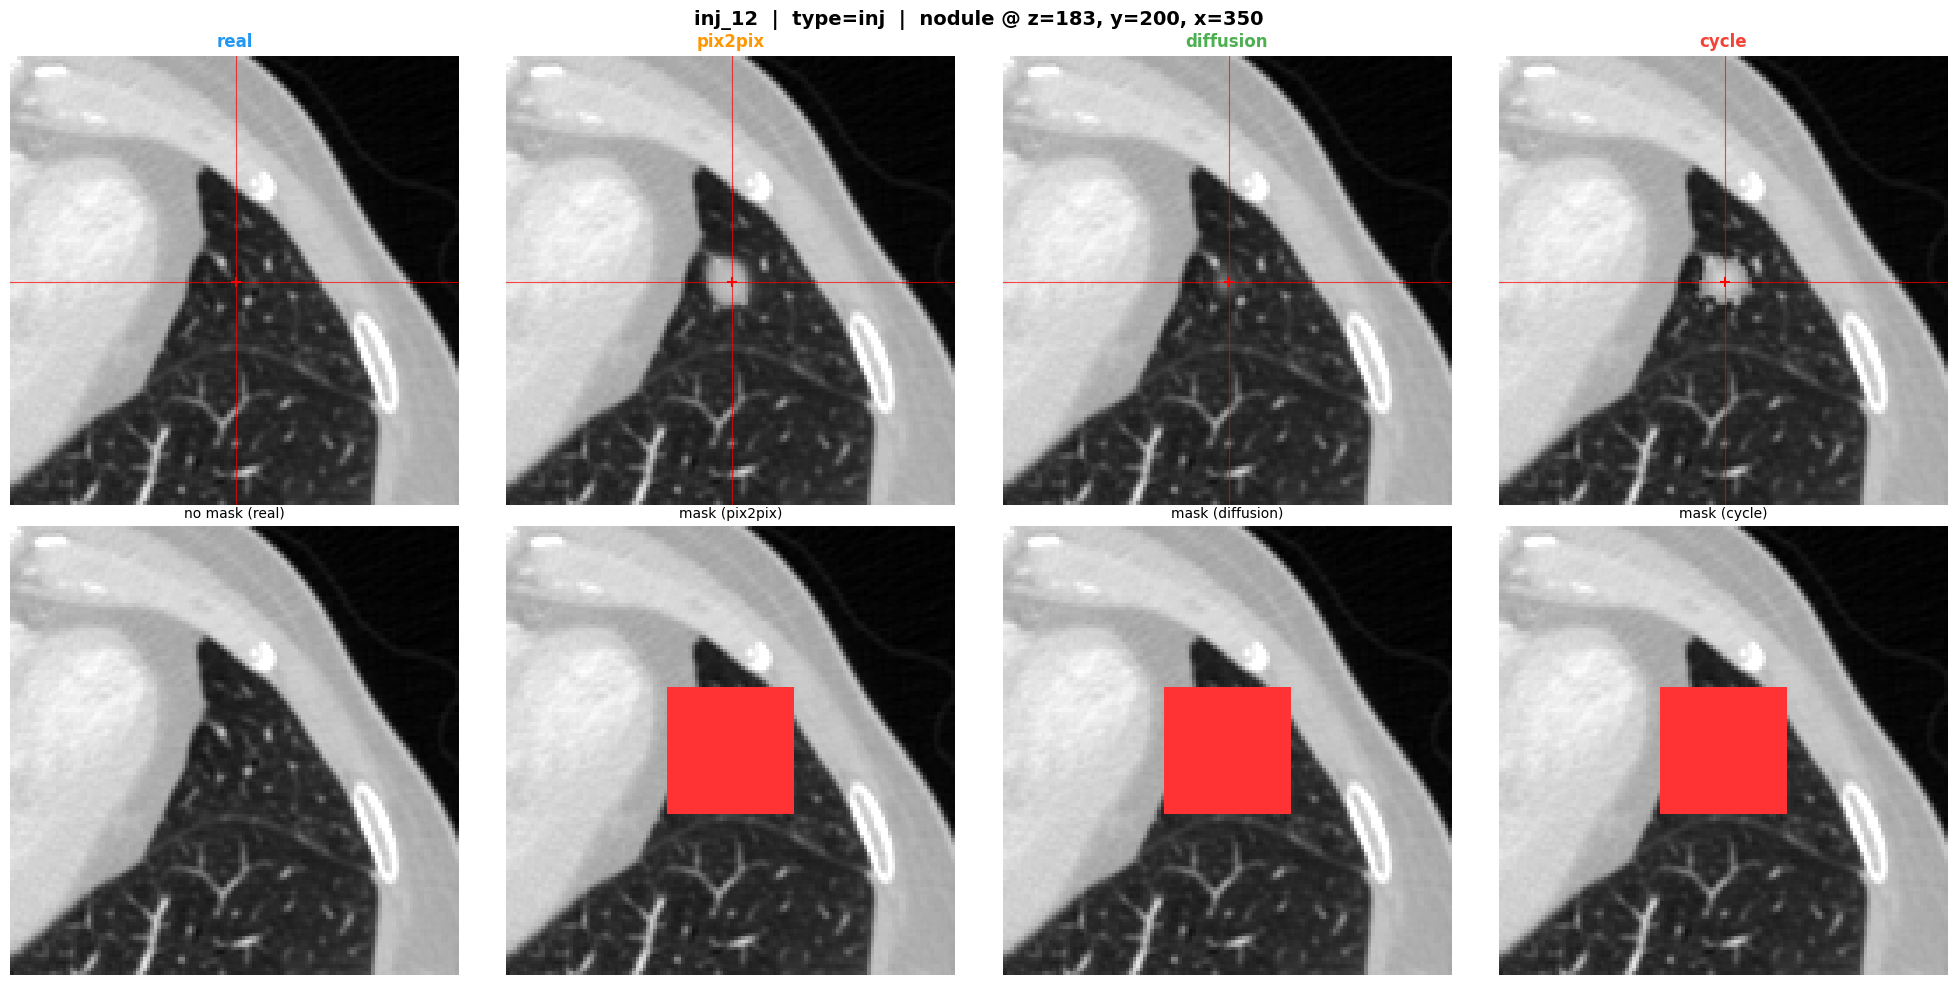

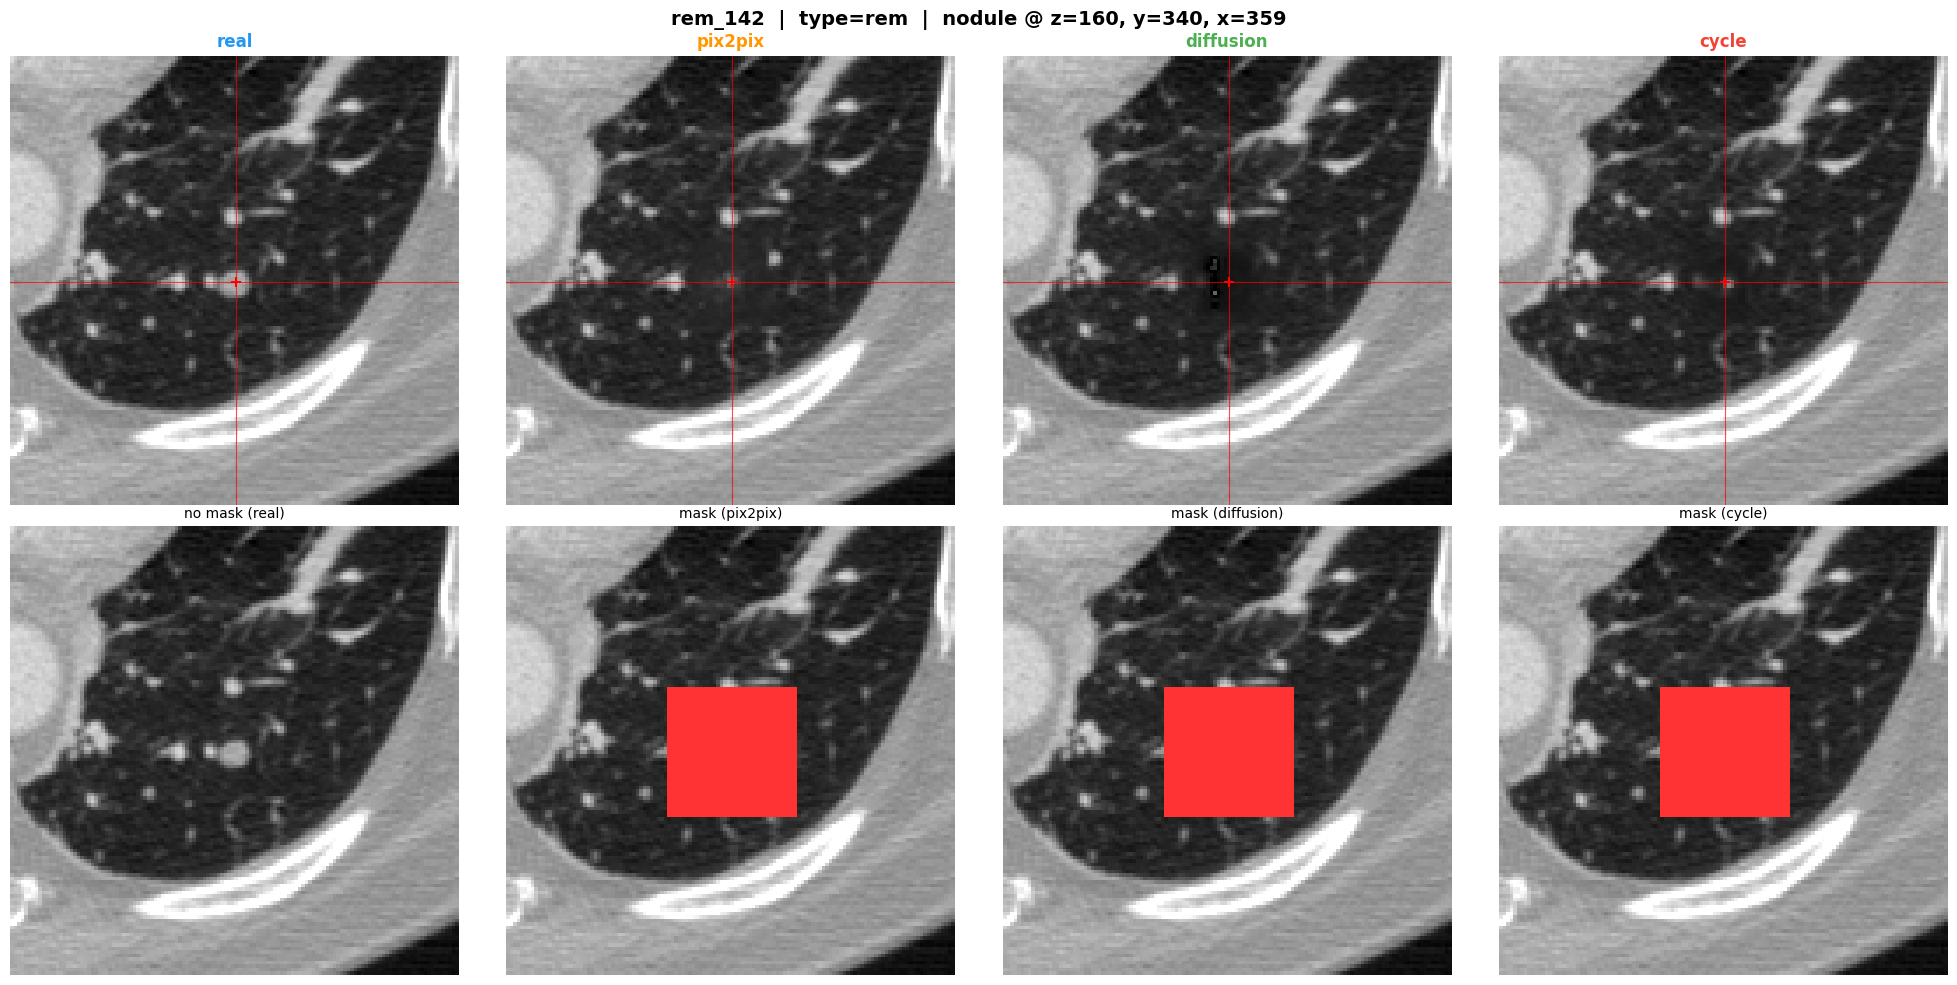

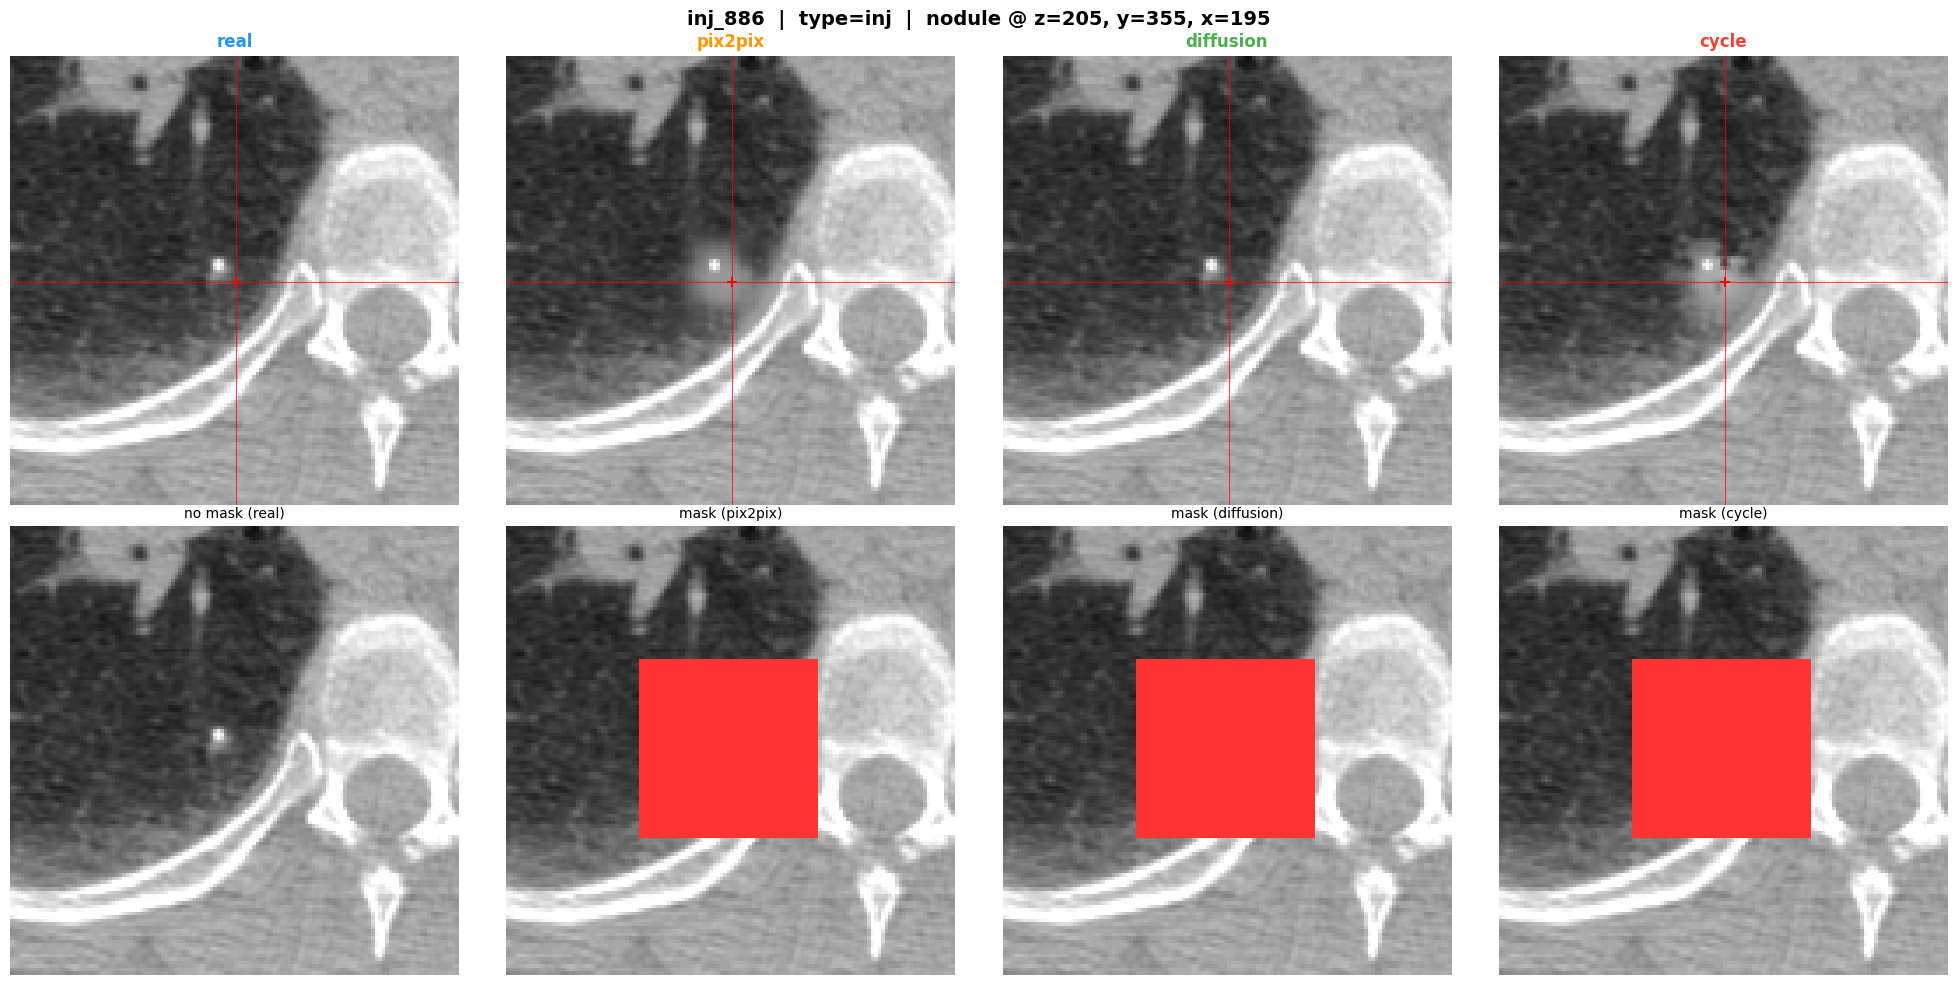

In [3]:
def show_2d_sample(img_id, crop=None, show_crosshair=True):
    """
    Show the slice at coord_z for all 4 modalities + mask overlay.
    crop: None = full 512×512 image
          int  = show only a crop×crop patch centred on the nodule
    show_crosshair: draw a red crosshair at the nodule centre
    """
    cz, cy, cx = get_coords(img_id)
    ty = data[data['img_id'] == img_id].iloc[0]['ty']

    fig, axes = plt.subplots(2, len(MODS), figsize=(5 * len(MODS), 10))
    fig.suptitle(f'{img_id}  |  type={ty}  |  nodule @ z={cz}, y={cy}, x={cx}',
                 fontsize=14, fontweight='bold')

    for col, mod in enumerate(MODS):
        # ── scan slice ──────────────────────────────────────────────────────
        sl = load_slice_norm(img_id, mod, cz)
        ax = axes[0, col]

        if sl is not None:
            if crop is not None:
                h = sl.shape[0]; w = sl.shape[1]
                y0 = max(0, cy - crop // 2); y1 = min(h, cy + crop // 2)
                x0 = max(0, cx - crop // 2); x1 = min(w, cx + crop // 2)
                sl_show = sl[y0:y1, x0:x1]
                # crosshair relative to the crop
                yc_rel = cy - y0; xc_rel = cx - x0
            else:
                sl_show = sl
                yc_rel = cy; xc_rel = cx

            ax.imshow(sl_show, cmap='gray', vmin=0, vmax=1)
            if show_crosshair:
                ax.axhline(yc_rel, color='red', lw=0.8, alpha=0.7)
                ax.axvline(xc_rel, color='red', lw=0.8, alpha=0.7)
                ax.scatter([xc_rel], [yc_rel], s=60, c='red', marker='+', linewidths=1.5)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)

        ax.set_title(mod, fontsize=12, fontweight='bold',
                     color=COLORS[mod])
        ax.axis('off')

        # ── mask ────────────────────────────────────────────────────────────
        mk = load_mask_slice(img_id, mod, cz)
        ax2 = axes[1, col]

        if mk is not None:
            if crop is not None:
                h = mk.shape[0]; w = mk.shape[1]
                y0 = max(0, cy - crop // 2); y1 = min(h, cy + crop // 2)
                x0 = max(0, cx - crop // 2); x1 = min(w, cx + crop // 2)
                mk_show = mk[y0:y1, x0:x1]
            else:
                mk_show = mk

            # overlay mask (red) on grey scan
            if sl is not None:
                sl_adj = sl[y0:y1, x0:x1] if crop is not None else sl
                rgb = np.stack([sl_adj, sl_adj, sl_adj], axis=-1)
                rgb[mk_show > 0] = [1, 0.2, 0.2]
                ax2.imshow(rgb, vmin=0, vmax=1)
            else:
                ax2.imshow(mk_show, cmap='Reds', vmin=0, vmax=1)
            ax2.set_title(f'mask ({mod})', fontsize=10)
        else:
            # for real: show scan without mask
            if sl is not None:
                sl_show = sl[max(0,cy-crop//2):min(sl.shape[0],cy+crop//2),
                             max(0,cx-crop//2):min(sl.shape[1],cx+crop//2)] if crop else sl
                ax2.imshow(sl_show, cmap='gray', vmin=0, vmax=1)
            ax2.set_title('no mask (real)', fontsize=10)
        ax2.axis('off')

    axes[0, 0].set_ylabel('CT slice', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Mask overlay', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── show the first 3 samples ─────────────────────────────────────────────────
for sid in SAMPLE_IDS[:3]:
    show_2d_sample(sid, crop=128)    # crop=None → full 512×512

---
## 3. Multi-sample Grid — Central Slice Only

All samples in `SAMPLE_IDS` in a single compact figure. Each row = one nodule; each column = one modality.

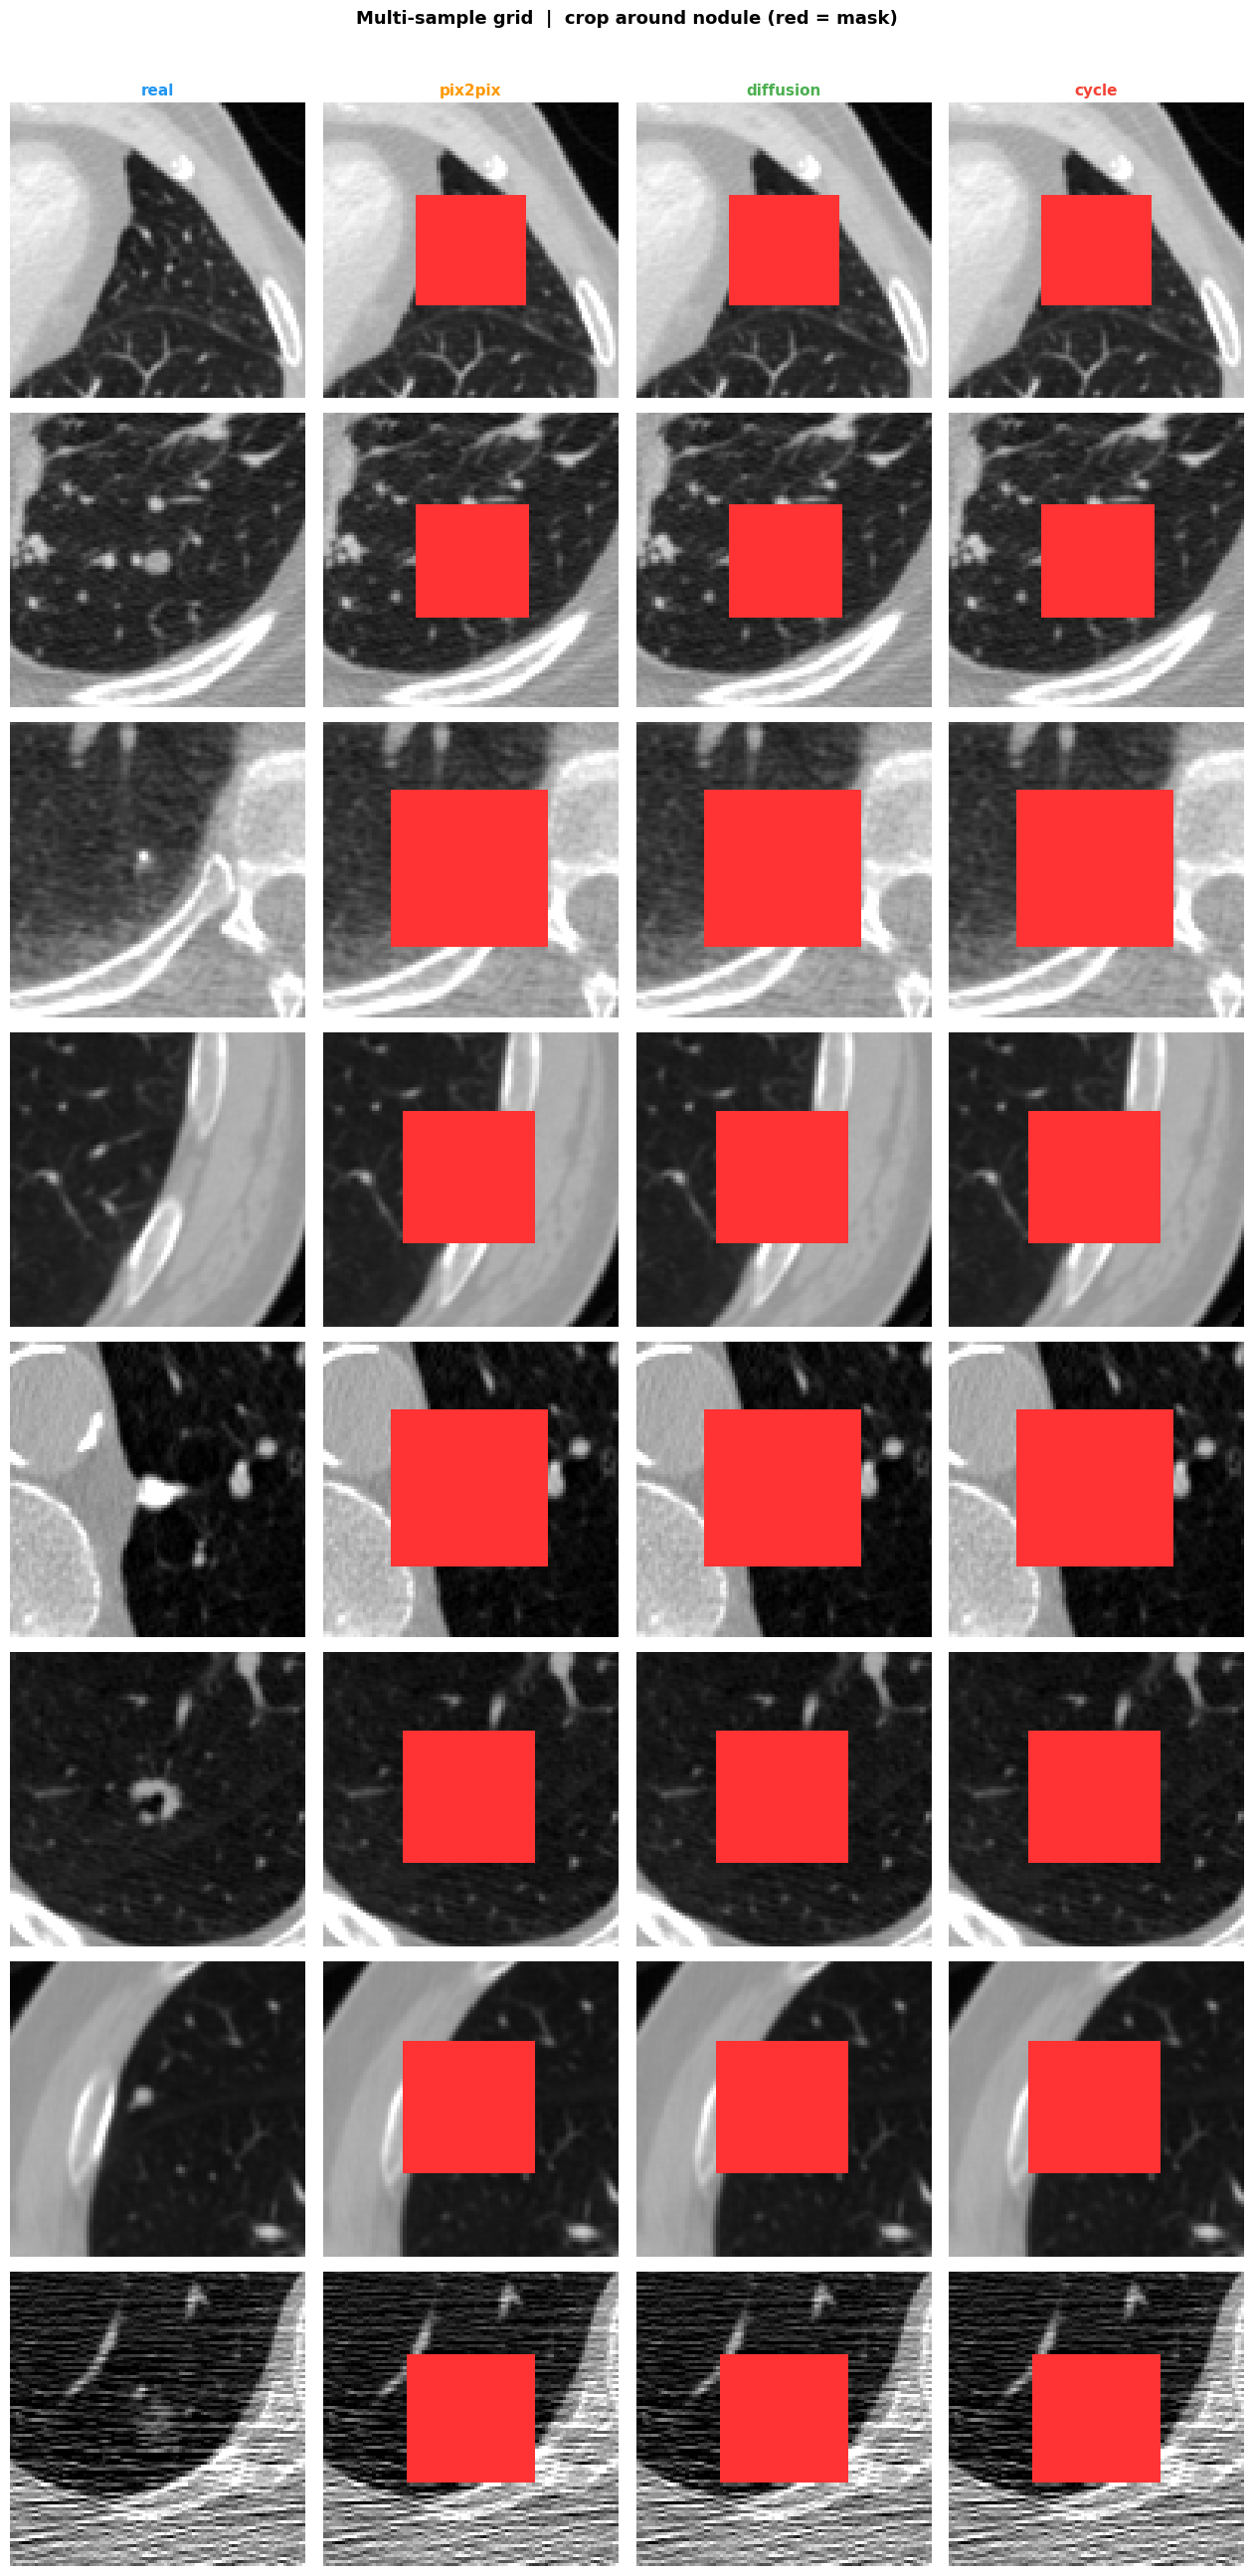

In [4]:
CROP_GRID = 96   # patch size in the grid

n_rows = len(SAMPLE_IDS)
n_cols = len(MODS)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(3.2 * n_cols, 3.2 * n_rows),
                          squeeze=False)

for r, sid in enumerate(SAMPLE_IDS):
    cz, cy, cx = get_coords(sid)
    ty = data[data['img_id'] == sid].iloc[0]['ty']
    y0, y1 = max(0, cy - CROP_GRID // 2), min(512, cy + CROP_GRID // 2)
    x0, x1 = max(0, cx - CROP_GRID // 2), min(512, cx + CROP_GRID // 2)

    for c, mod in enumerate(MODS):
        ax = axes[r, c]
        sl = load_slice_norm(sid, mod, cz)
        if sl is not None:
            patch = sl[y0:y1, x0:x1]
            mk    = load_mask_slice(sid, mod, cz)

            rgb = np.stack([patch, patch, patch], axis=-1)
            if mk is not None:
                mk_patch = mk[y0:y1, x0:x1]
                rgb[mk_patch > 0] = [1, 0.2, 0.2]

            ax.imshow(rgb, vmin=0, vmax=1)
        else:
            ax.set_facecolor('#222')

        ax.axis('off')
        if r == 0:
            ax.set_title(mod, fontsize=11, fontweight='bold', color=COLORS[mod])
        if c == 0:
            ax.set_ylabel(f'{sid}\n({ty})', fontsize=8, rotation=0,
                          labelpad=60, va='center')

fig.suptitle('Multi-sample grid  |  crop around nodule (red = mask)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Difference Heatmap — Real vs Fake

For each fake architecture: real scan • fake scan • amplified difference (RdBu_r) • binary mask.

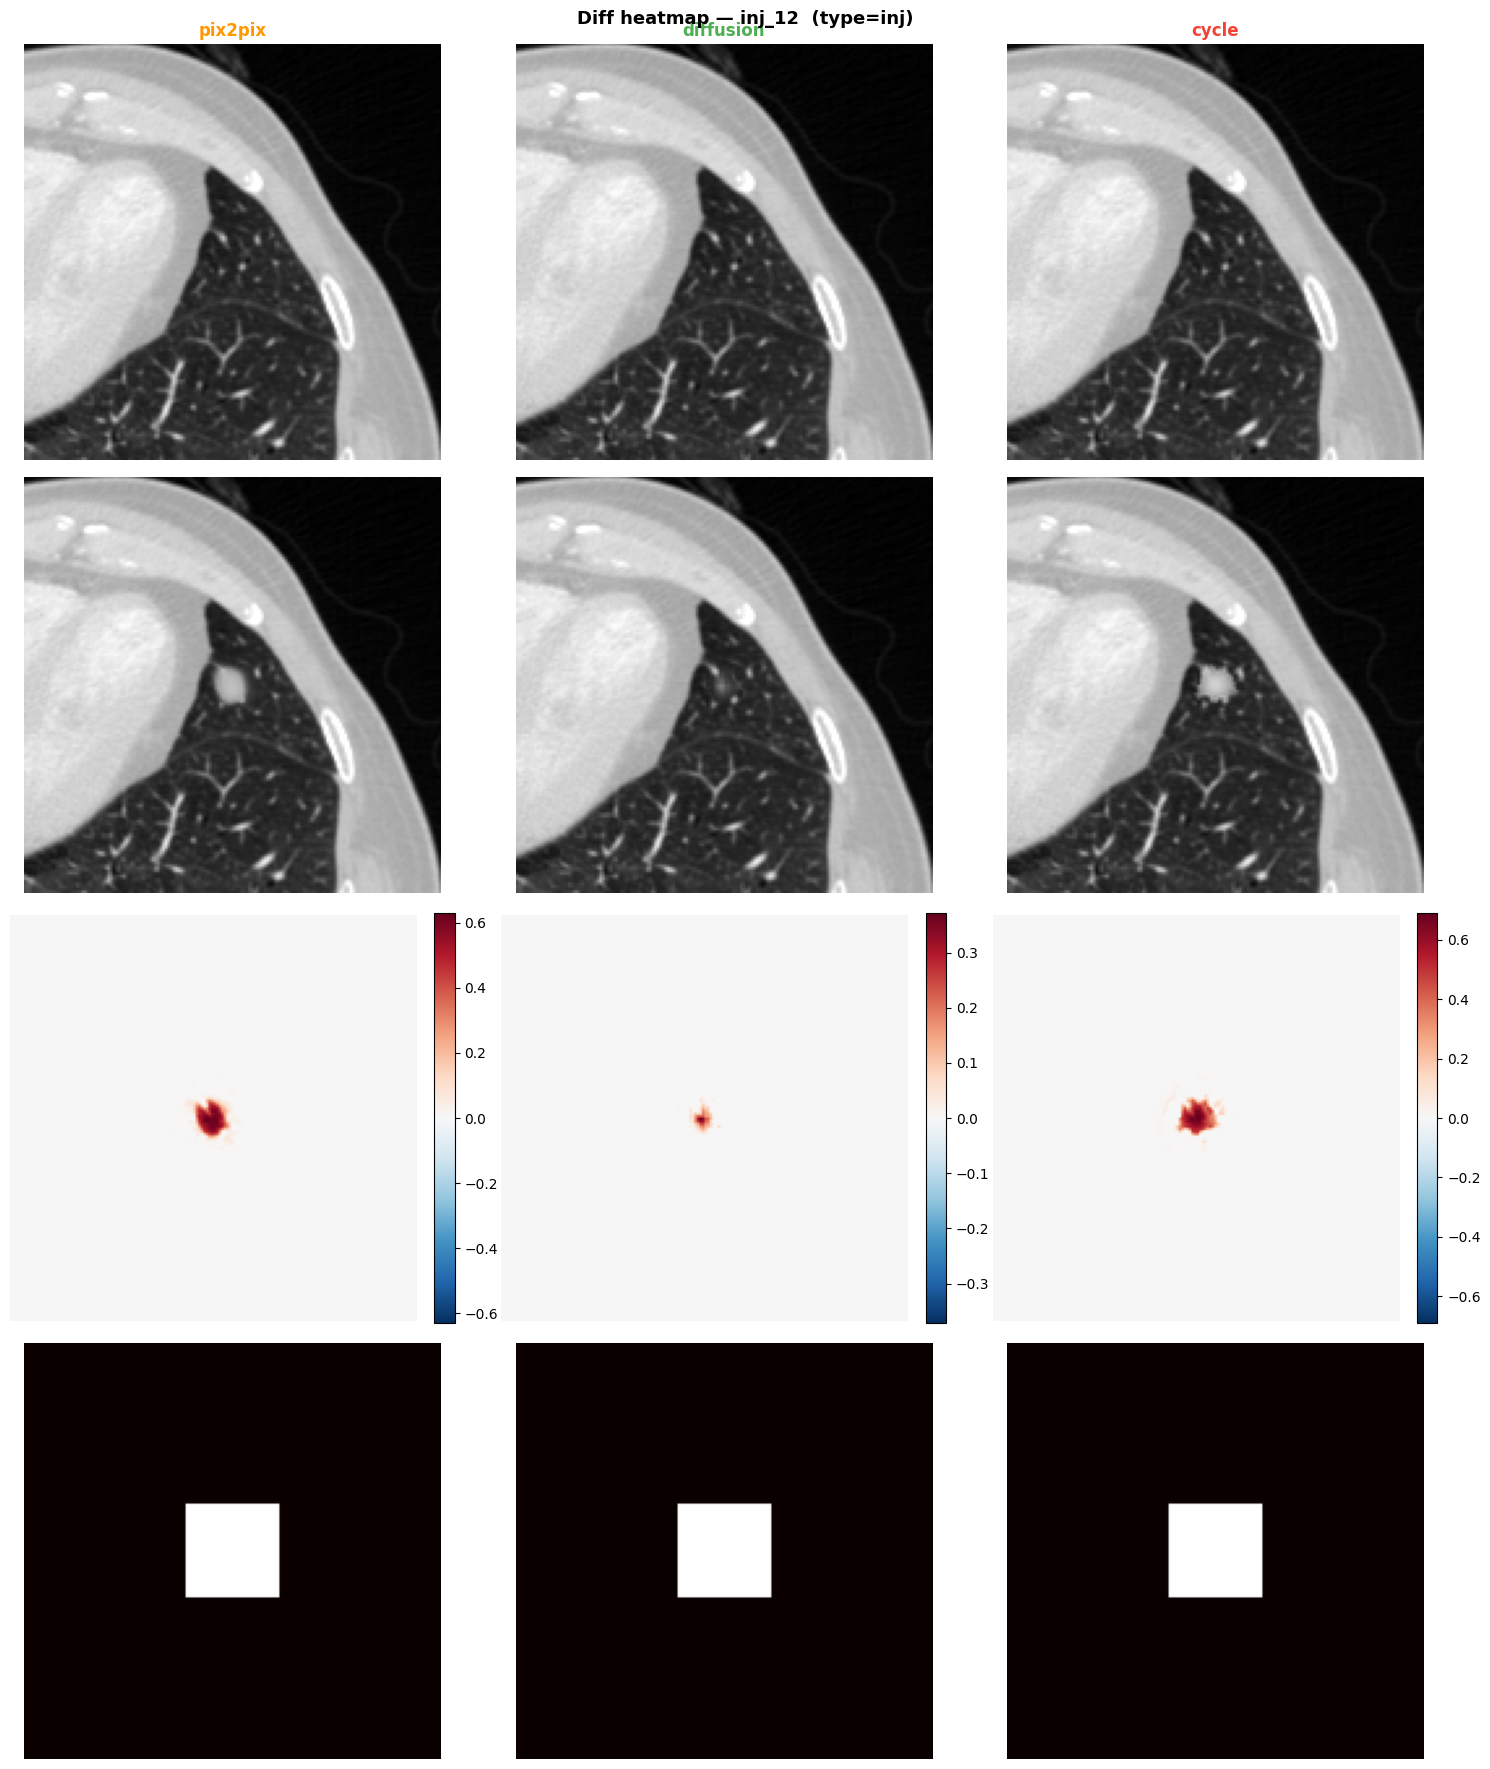

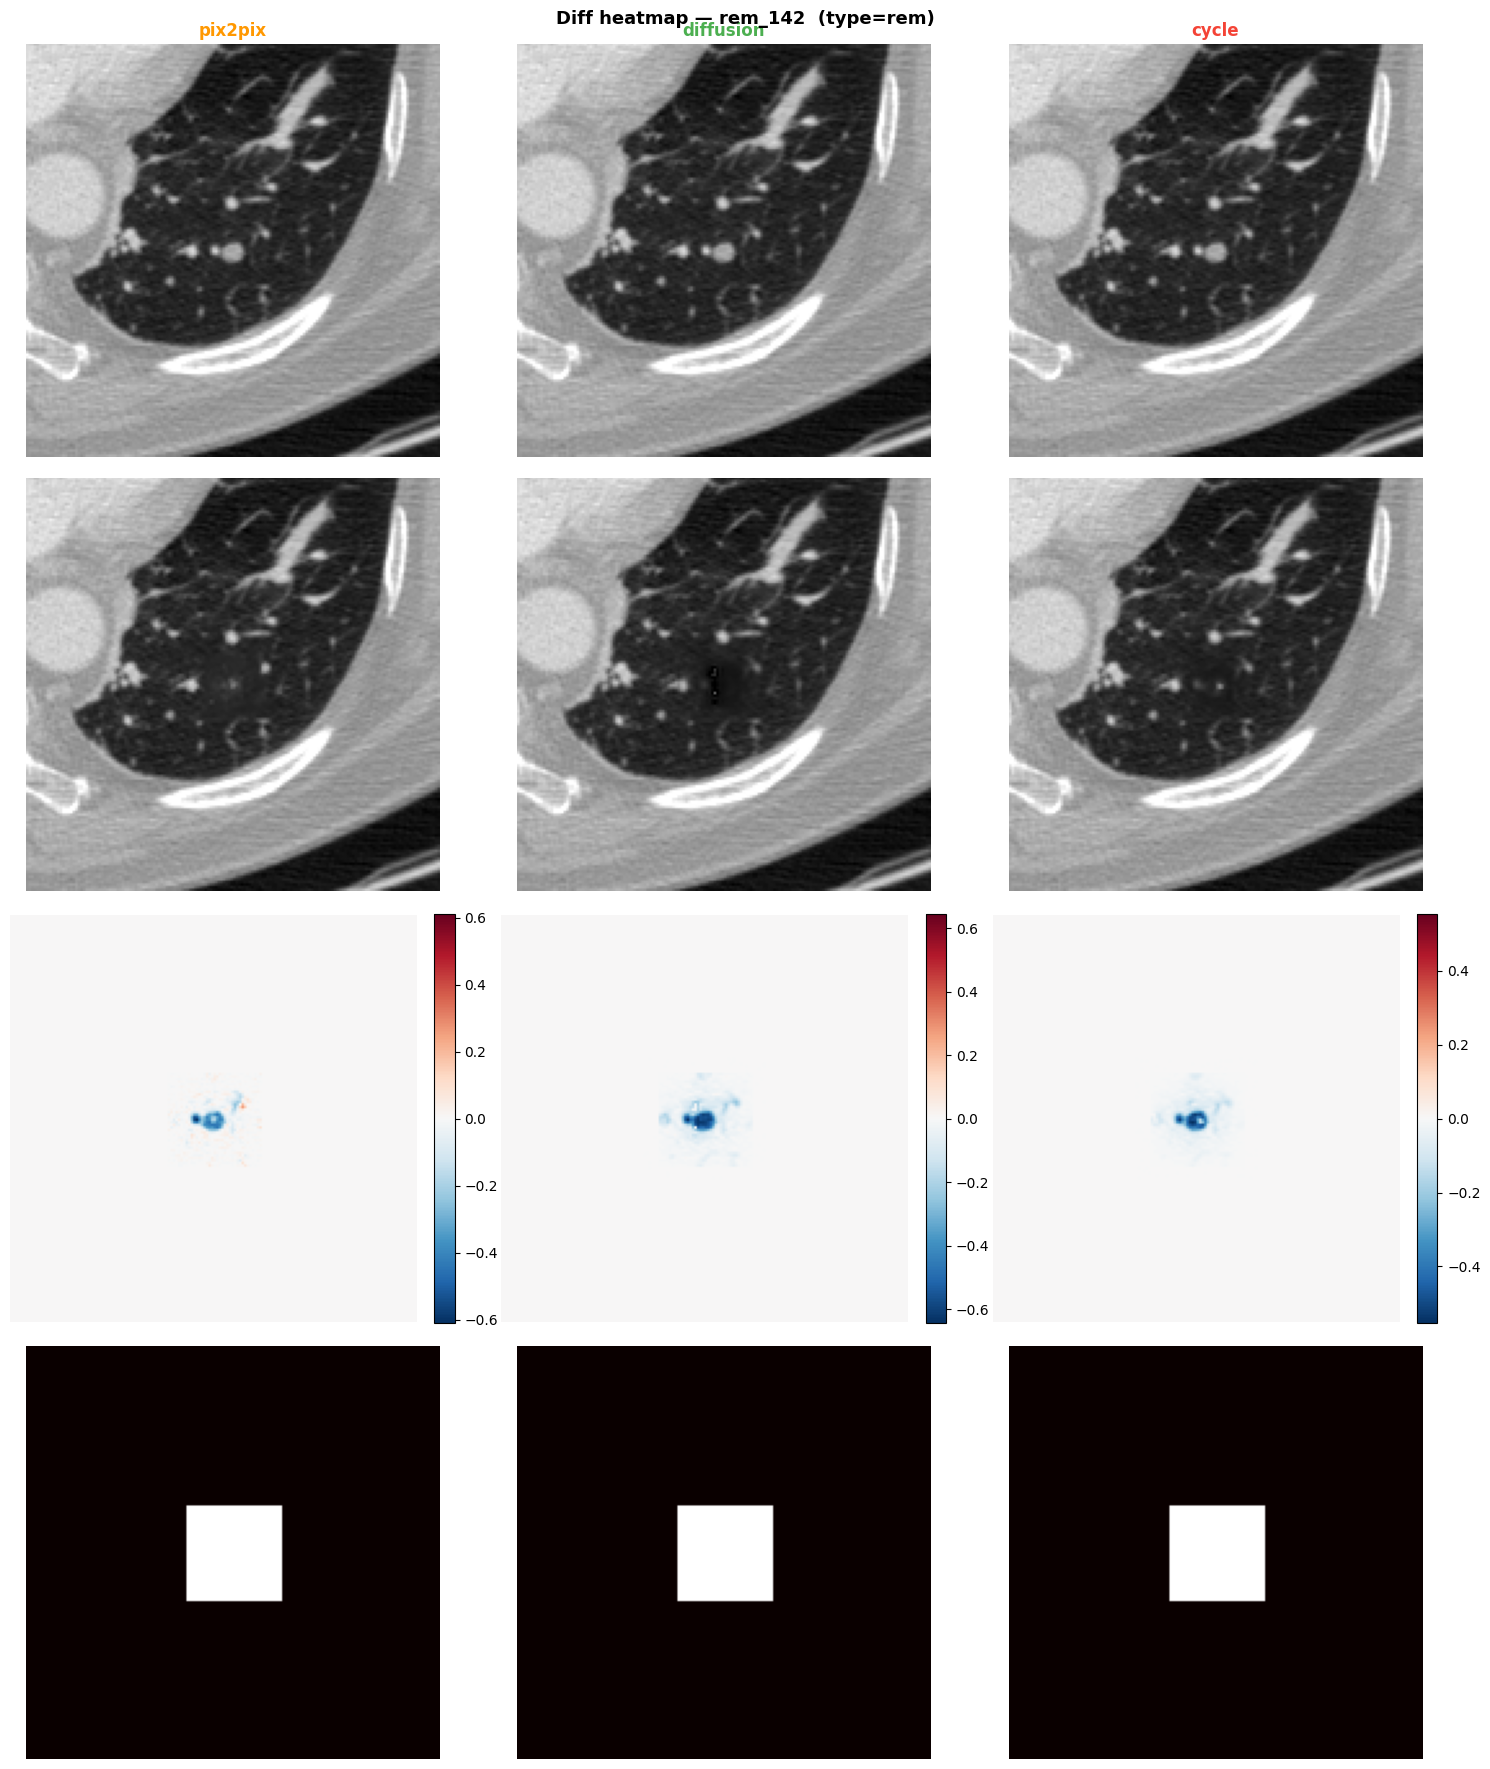

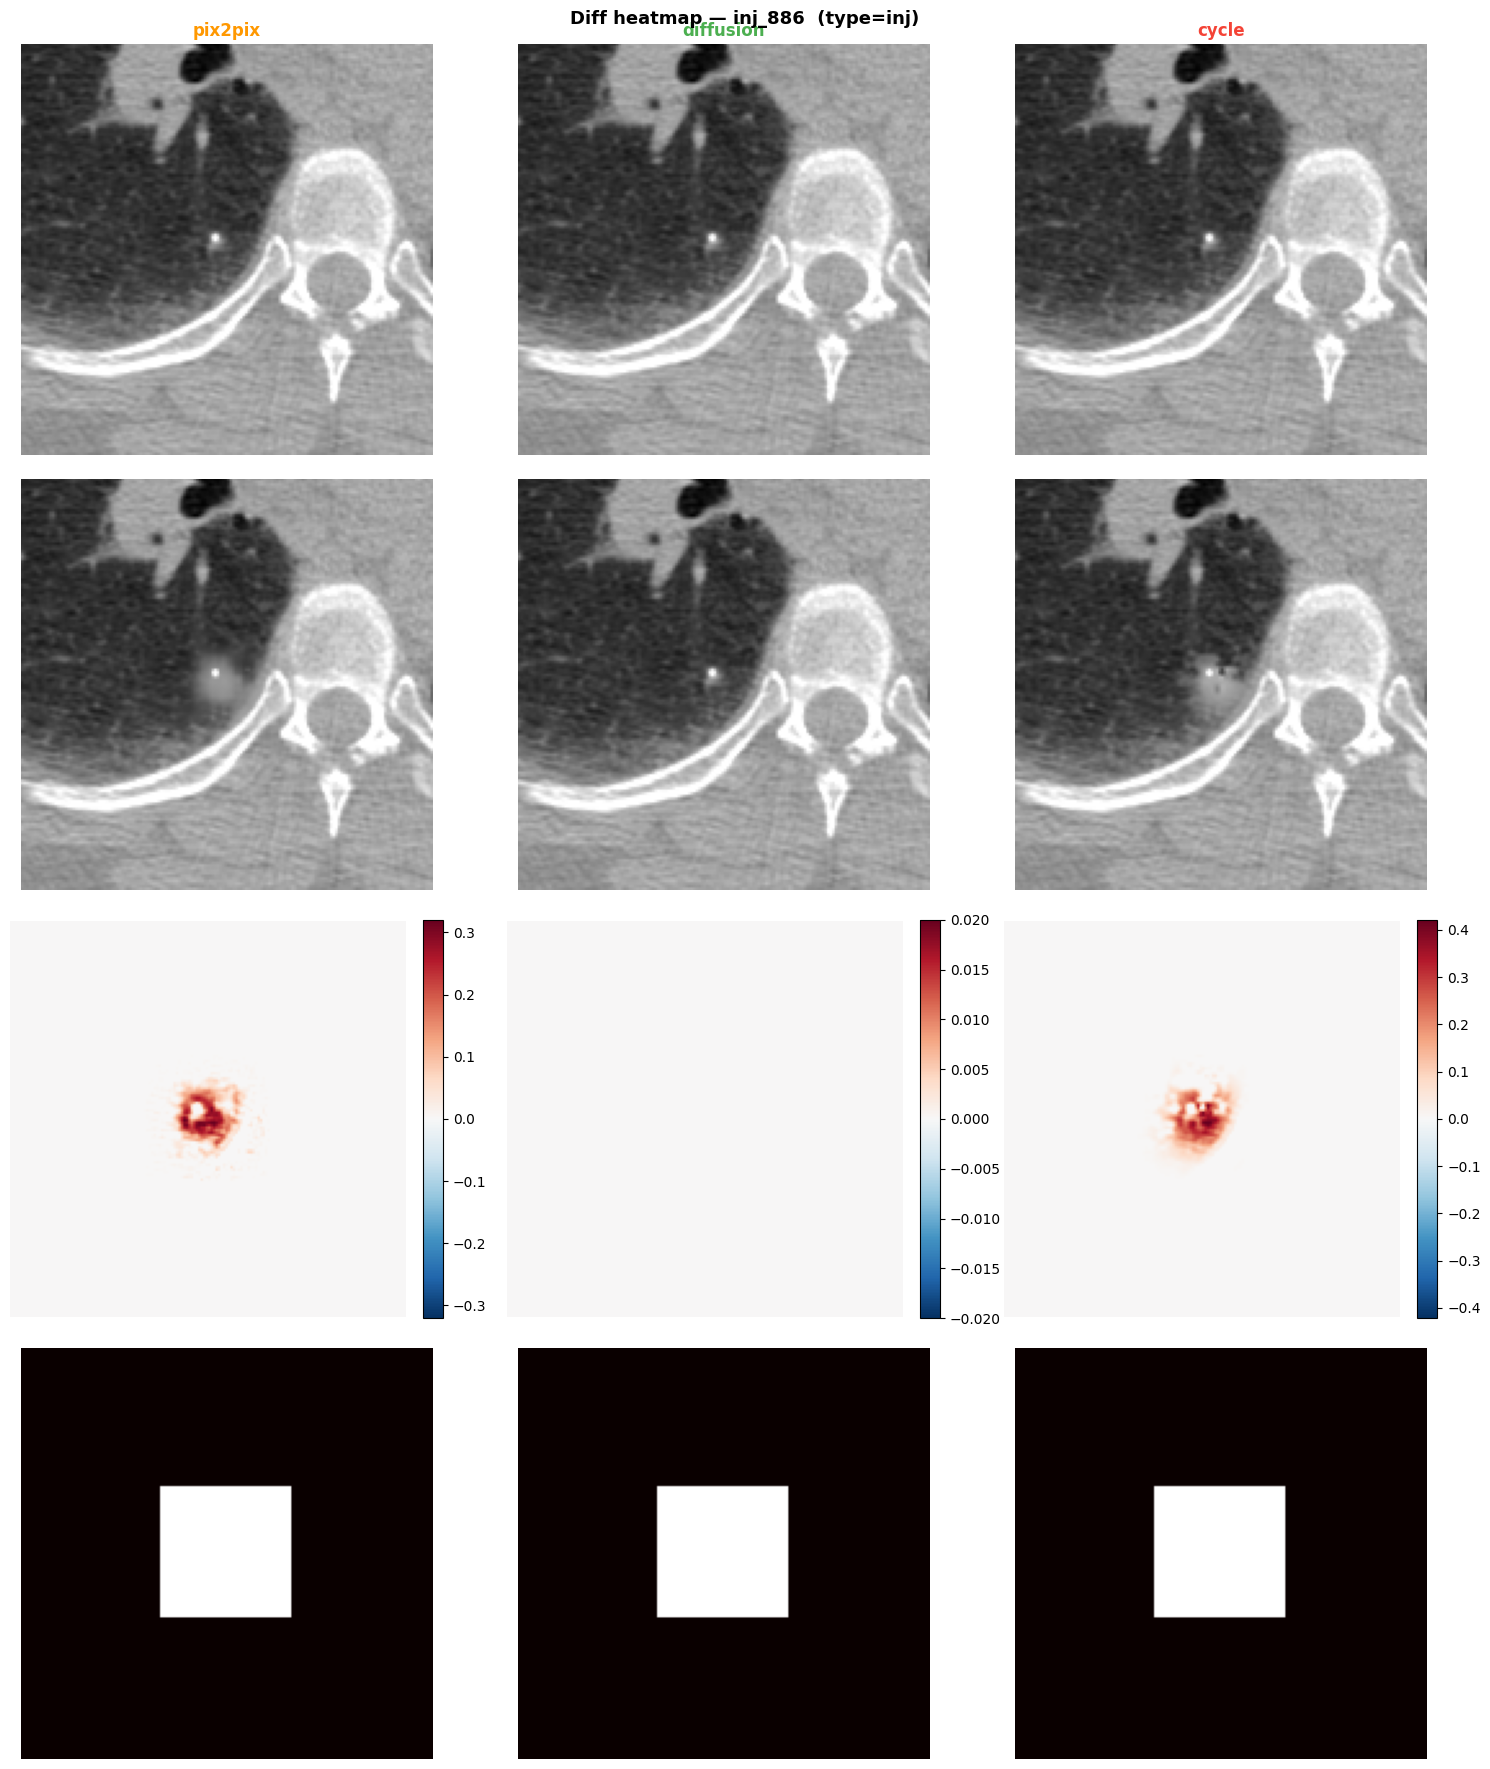

In [5]:
def show_diff_heatmap(img_id, crop=160):
    """
    4 rows × 3 columns (one per fake architecture):
      row 0 = real | row 1 = fake | row 2 = diff | row 3 = mask
    """
    cz, cy, cx = get_coords(img_id)
    ty = data[data['img_id'] == img_id].iloc[0]['ty']
    fake_mods = [m for m in MODS if m != 'real']

    sl_real = load_slice_norm(img_id, 'real', cz)
    if sl_real is None:
        print(f"[SKIP] {img_id}: real scan not found"); return

    y0 = max(0, cy - crop // 2); y1 = min(512, cy + crop // 2)
    x0 = max(0, cx - crop // 2); x1 = min(512, cx + crop // 2)
    real_crop = sl_real[y0:y1, x0:x1]

    fig, axes = plt.subplots(4, len(fake_mods),
                              figsize=(5 * len(fake_mods), 18))
    labels = ['Real', 'Fake', 'Difference  (fake − real)', 'Mask']
    row_cmaps = ['gray', 'gray', 'RdBu_r', 'hot']

    for col, mod in enumerate(fake_mods):
        sl_fake = load_slice_norm(img_id, mod, cz)
        mk      = load_mask_slice(img_id, mod, cz)

        fake_crop = sl_fake[y0:y1, x0:x1] if sl_fake is not None else np.zeros_like(real_crop)
        diff_crop = fake_crop - real_crop
        vmax      = max(np.abs(diff_crop).max(), 0.02)
        mk_crop   = mk[y0:y1, x0:x1].astype(float) if mk is not None else np.zeros_like(real_crop)

        imgs   = [real_crop, fake_crop, diff_crop, mk_crop]
        clims  = [(0, 1), (0, 1), (-vmax, vmax), (0, 1)]

        for row in range(4):
            ax = axes[row, col]
            im = ax.imshow(imgs[row], cmap=row_cmaps[row],
                           vmin=clims[row][0], vmax=clims[row][1])
            if row == 2:
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.axis('off')
            if row == 0:
                ax.set_title(mod, fontsize=12, fontweight='bold', color=COLORS[mod])

    for row, lbl in enumerate(labels):
        axes[row, 0].set_ylabel(lbl, fontsize=10, fontweight='bold',
                                 rotation=0, labelpad=80, va='center')

    fig.suptitle(f'Diff heatmap — {img_id}  (type={ty})', fontsize=13,
                 fontweight='bold')
    plt.tight_layout()
    plt.show()


for sid in SAMPLE_IDS[:3]:
    show_diff_heatmap(sid, crop=160)

---
## 5. Interactive 2D Viewer — Z Slider

Scroll through the Z axis of a volume for all 4 modalities simultaneously. Use the widgets below to select the sample and slice.

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib
matplotlib.rcParams['figure.dpi'] = 90

# Pre-load volumes for the selected img_id to speed up the slider
_vol_cache = {}

def _ensure_loaded(img_id):
    if img_id not in _vol_cache:
        cz, cy, cx = get_coords(img_id)
        vols  = {}
        masks = {}
        for mod in MODS:
            vols[mod]  = load_cube(img_id, mod, cz, cy, cx, half=HALF_CUBE)
        _vol_cache[img_id] = {'vols': vols, 'coord': (cz, cy, cx)}


def interactive_z_viewer(img_id='inj_12', z_offset=0, crop_patch=False):
    _ensure_loaded(img_id)
    data_cache = _vol_cache[img_id]
    cz, cy, cx = data_cache['coord']
    vols       = data_cache['vols']

    # z_offset is relative to the centre of the loaded cube
    cube_depth = list(v.shape[0] for v in vols.values() if v is not None)[0]
    z_idx      = max(0, min(cube_depth - 1, cube_depth // 2 + z_offset))

    fig, axes = plt.subplots(1, len(MODS), figsize=(4 * len(MODS), 4.5))
    fig.suptitle(f'{img_id}  |  local slice z={z_idx}  (nodule @ z_global={cz})',
                 fontsize=12, fontweight='bold')

    for col, mod in enumerate(MODS):
        vol = vols.get(mod)
        ax  = axes[col]
        if vol is not None and z_idx < vol.shape[0]:
            sl = vol[z_idx]                          # (H, W)
            ax.imshow(sl, cmap='gray', vmin=0, vmax=1)
            # red dot at nodule centre
            cy_crop = sl.shape[0] // 2
            cx_crop = sl.shape[1] // 2
            ax.axhline(cy_crop, color='red', lw=0.6, alpha=0.5)
            ax.axvline(cx_crop, color='red', lw=0.6, alpha=0.5)
        else:
            ax.set_facecolor('#111')
        ax.set_title(mod, fontsize=11, fontweight='bold', color=COLORS[mod])
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# ── widget controls ──────────────────────────────────────────────────────────
id_widget = widgets.Dropdown(
    options=SAMPLE_IDS, value=SAMPLE_IDS[0], description='Nodule:',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='220px'))

z_widget  = widgets.IntSlider(
    value=0, min=-HALF_CUBE + 1, max=HALF_CUBE - 1, step=1,
    description='Z offset:', continuous_update=False,
    style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))

ui = widgets.HBox([id_widget, z_widget])
out = widgets.interactive_output(interactive_z_viewer,
                                  {'img_id': id_widget, 'z_offset': z_widget})
display(ui, out)

Output()

---
## 6. 3D Visualisation — Orthogonal Views (Axial · Coronal · Sagittal)

For each modality, the 3 orthogonal views of the cube centred on the nodule are shown.  
- **Axial** = XY plane at the central Z  
- **Coronal** = XZ plane at the central Y  
- **Sagittal** = YZ plane at the central X

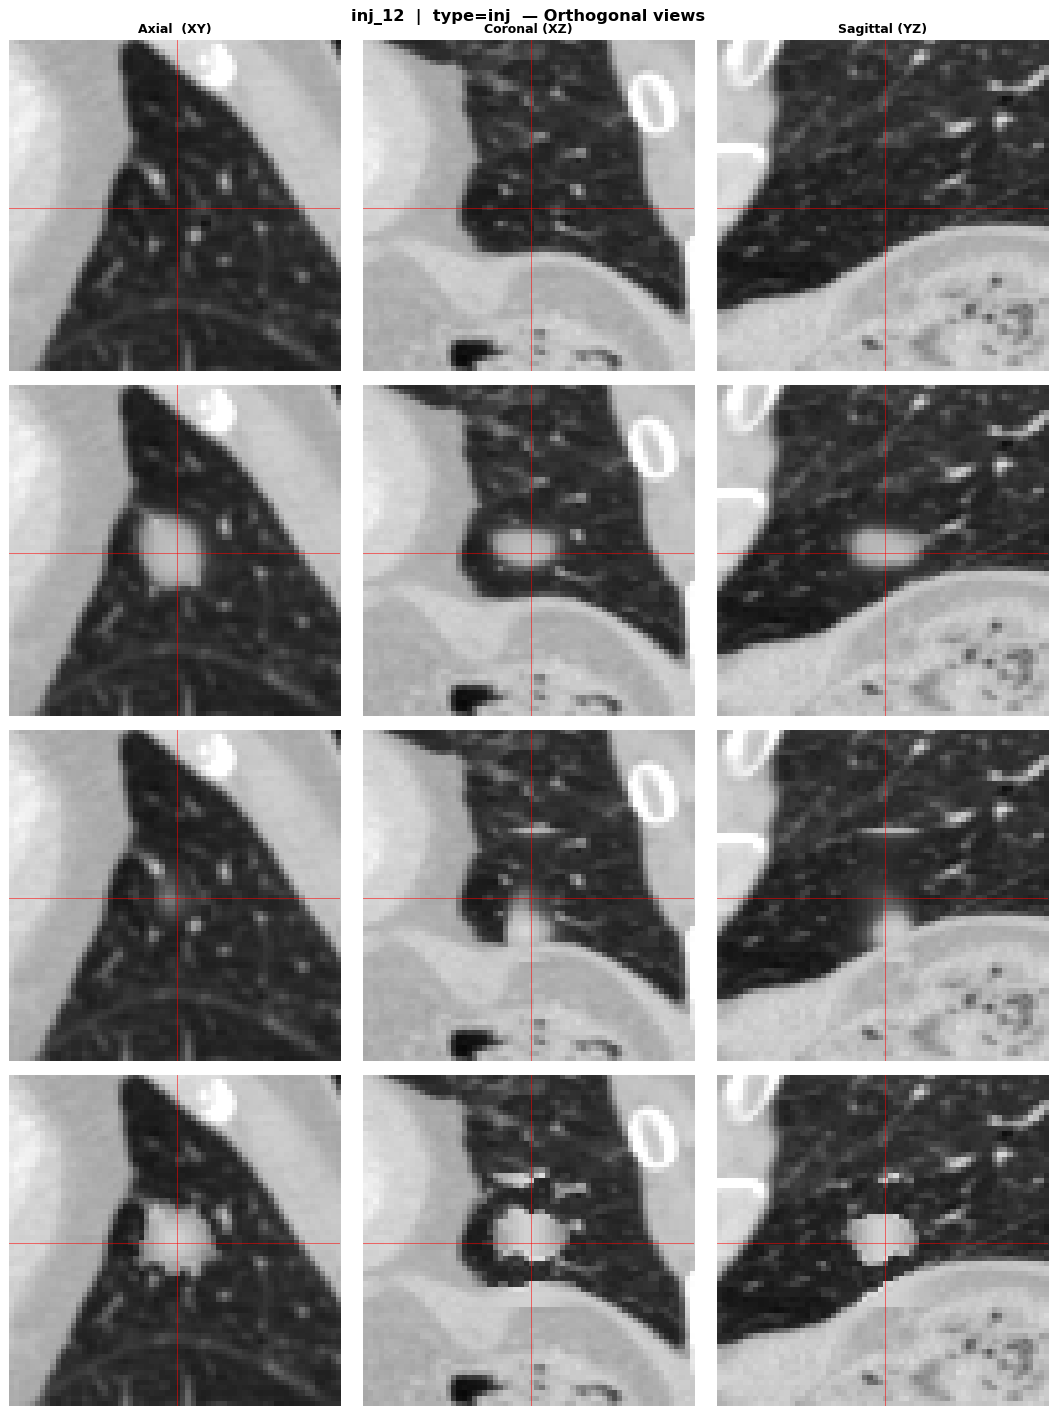

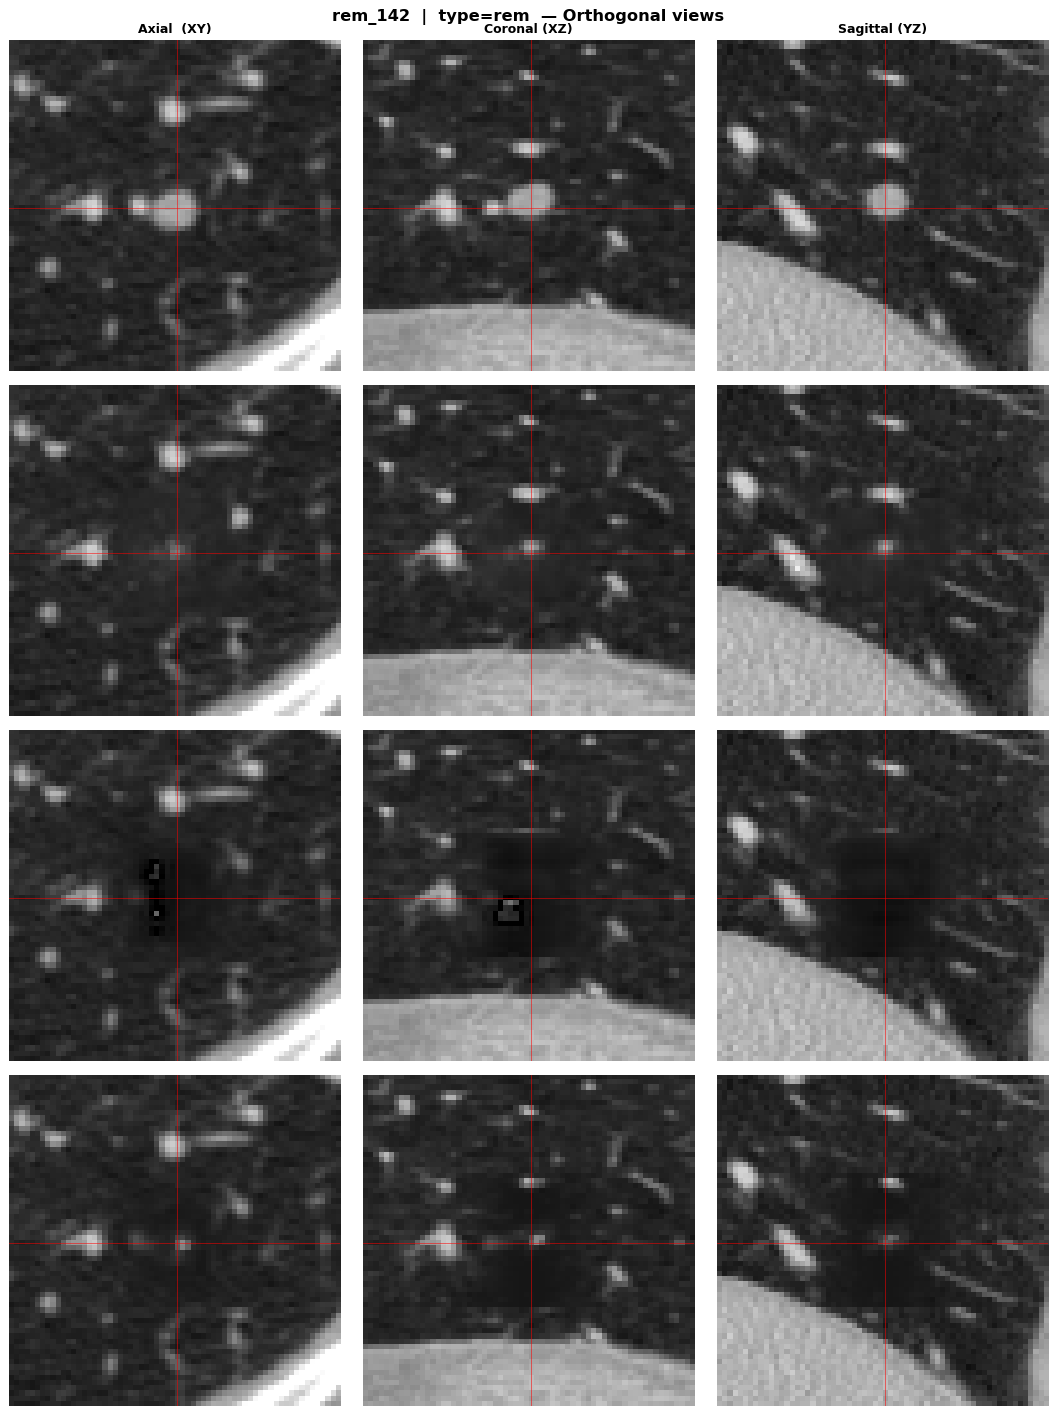

In [7]:
def show_orthogonal(img_id, half=HALF_CUBE):
    """
    Orthogonal views of the 3D cube for all 4 modalities.
    Rows: modality   Columns: Axial / Coronal / Sagittal
    """
    cz, cy, cx = get_coords(img_id)
    ty = data[data['img_id'] == img_id].iloc[0]['ty']

    view_labels = ['Axial  (XY)', 'Coronal (XZ)', 'Sagittal (YZ)']
    fig, axes   = plt.subplots(len(MODS), 3,
                                figsize=(12, 4 * len(MODS)))
    fig.suptitle(f'{img_id}  |  type={ty}  — Orthogonal views',
                 fontsize=13, fontweight='bold')

    for row, mod in enumerate(MODS):
        cube = load_cube(img_id, mod, cz, cy, cx, half=half)
        if cube is None:
            for c in range(3): axes[row, c].axis('off')
            continue

        D, H, W = cube.shape
        cz_l, cy_l, cx_l = D // 2, H // 2, W // 2  # local cube centre

        views = [
            cube[cz_l, :, :],          # Axial
            cube[:, cy_l, :],          # Coronal
            cube[:, :, cx_l],          # Sagittal
        ]
        lines = [
            ((cy_l, cx_l), ('h', 'v')),   # axial crosshair
            ((cz_l, cx_l), ('h', 'v')),   # coronal crosshair
            ((cz_l, cy_l), ('h', 'v')),   # sagittal crosshair
        ]

        for col, (view, (yc, xc), (_, _)) in enumerate(
                zip(views, [(cy_l, cx_l), (cz_l, cx_l), (cz_l, cy_l)],
                    lines)):
            ax = axes[row, col]
            ax.imshow(view, cmap='gray', vmin=0, vmax=1, aspect='equal')
            ax.axhline(yc, color='red', lw=0.7, alpha=0.6)
            ax.axvline(xc, color='red', lw=0.7, alpha=0.6)
            ax.axis('off')
            if row == 0:
                ax.set_title(view_labels[col], fontsize=10, fontweight='bold')
        axes[row, 0].set_ylabel(mod, fontsize=11, fontweight='bold',
                                 color=COLORS[mod], rotation=0,
                                 labelpad=70, va='center')

    plt.tight_layout()
    plt.show()


for sid in SAMPLE_IDS[:2]:
    show_orthogonal(sid)

---
## 7. Maximum Intensity Projection (MIP)

MIP projects the maximum voxel value along each direction. Useful for seeing the nodule shape without picking a single slice.

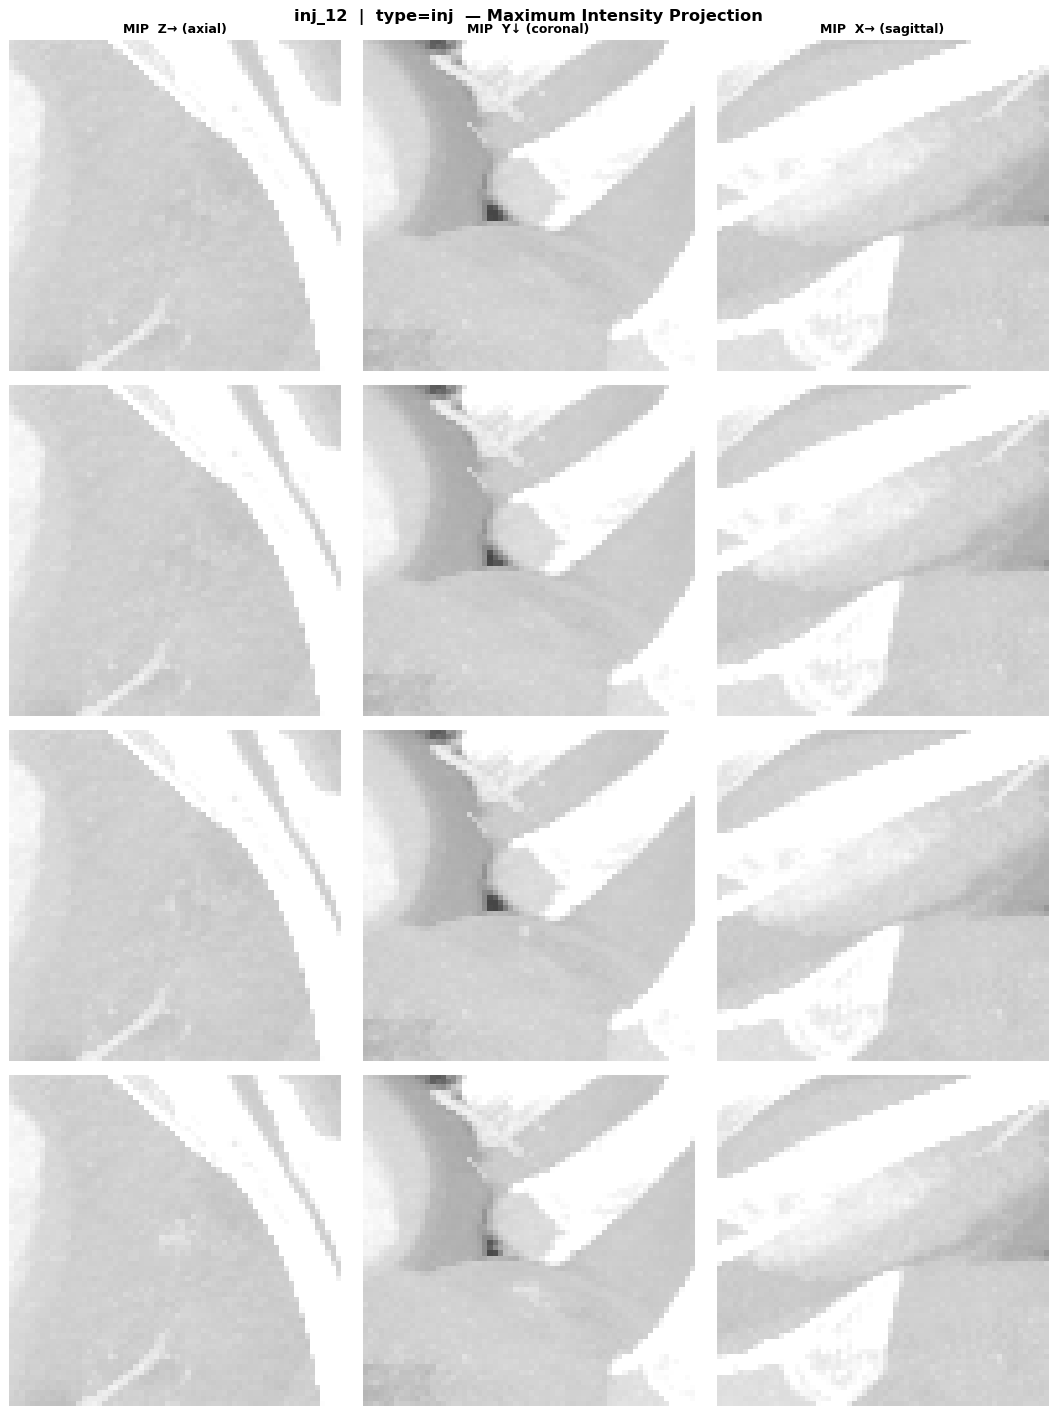

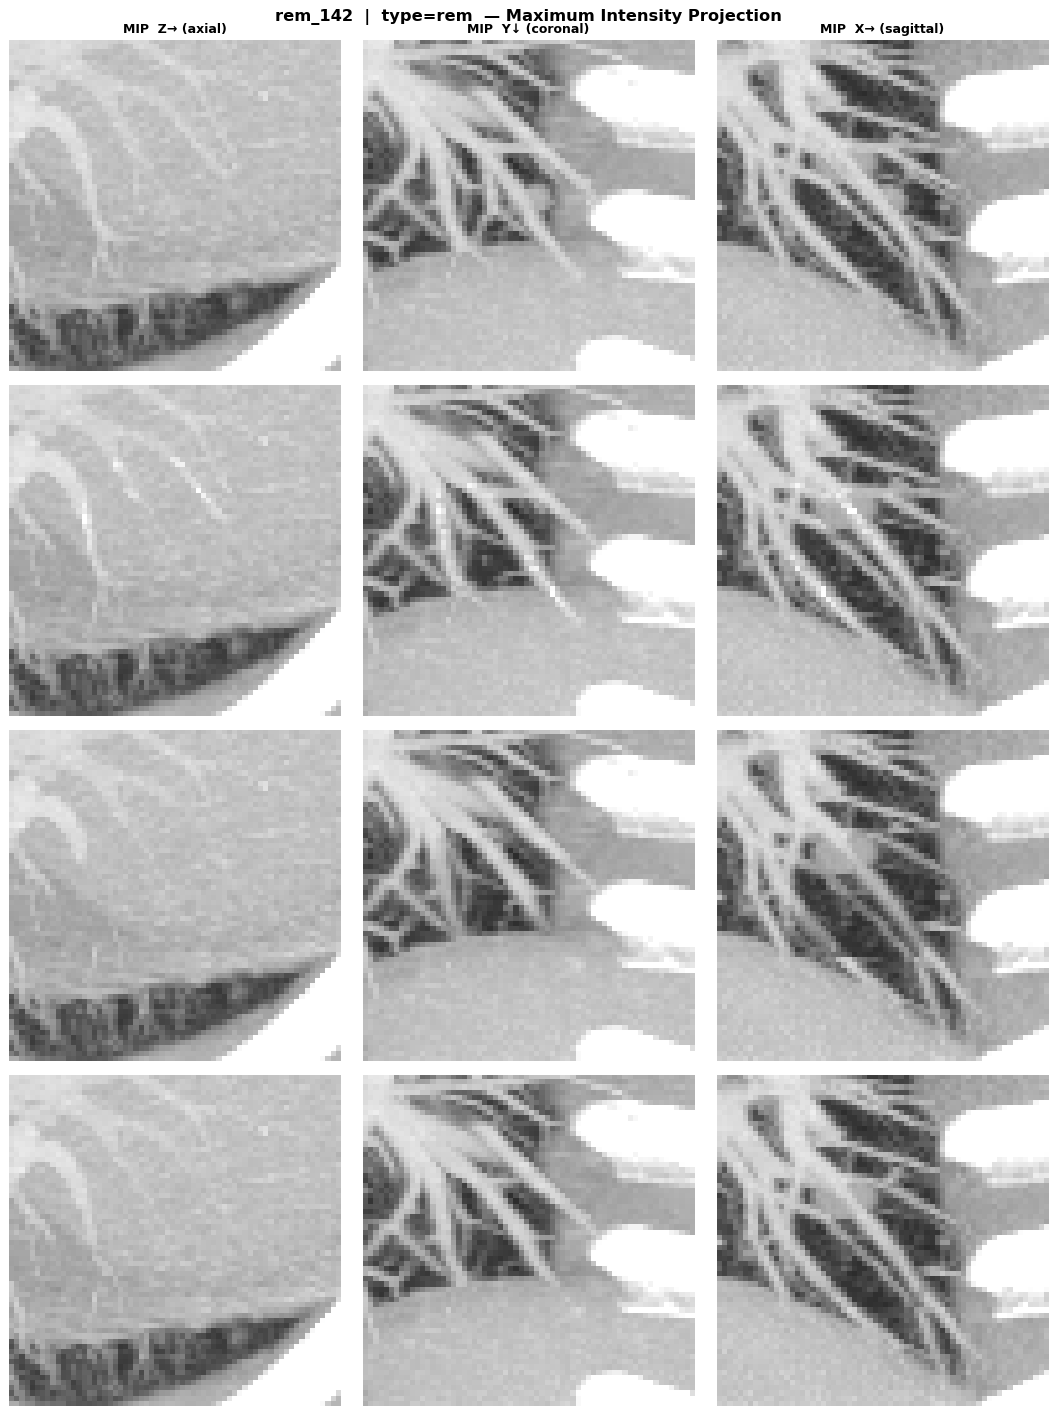

In [8]:
def show_mip(img_id, half=HALF_CUBE):
    """
    Maximum Intensity Projection along 3 axes for all 4 modalities.
    Each row = modality  |  columns = MIP-Z, MIP-Y, MIP-X
    """
    cz, cy, cx = get_coords(img_id)
    ty = data[data['img_id'] == img_id].iloc[0]['ty']

    axis_labels = ['MIP  Z→ (axial)', 'MIP  Y↓ (coronal)', 'MIP  X→ (sagittal)']
    fig, axes   = plt.subplots(len(MODS), 3, figsize=(12, 4 * len(MODS)))
    fig.suptitle(f'{img_id}  |  type={ty}  — Maximum Intensity Projection',
                 fontsize=13, fontweight='bold')

    for row, mod in enumerate(MODS):
        cube = load_cube(img_id, mod, cz, cy, cx, half=half)
        if cube is None:
            for c in range(3): axes[row, c].axis('off')
            continue

        mips = [
            cube.max(axis=0),   # MIP along Z (→ axial view shape H×W)
            cube.max(axis=1),   # MIP along Y (→ coronal view shape D×W)
            cube.max(axis=2),   # MIP along X (→ sagittal view shape D×H)
        ]

        for col, mip in enumerate(mips):
            ax = axes[row, col]
            ax.imshow(mip, cmap='gray', vmin=0, vmax=1, aspect='equal')
            ax.axis('off')
            if row == 0:
                ax.set_title(axis_labels[col], fontsize=10, fontweight='bold')

        axes[row, 0].set_ylabel(mod, fontsize=11, fontweight='bold',
                                 color=COLORS[mod], rotation=0,
                                 labelpad=70, va='center')

    plt.tight_layout()
    plt.show()


for sid in SAMPLE_IDS[:2]:
    show_mip(sid)

---
## 8. Interactive 3D Rendering — Plotly Volume

Interactive volumetric visualisation with Plotly. The cube is sub-sampled for performance.  
Rotate, zoom and adjust isovalues with the mouse.

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plotly_volume_3d(img_id, mod='real', half=HALF_CUBE,
                      downsample=2, isomin=0.25, isomax=0.85,
                      surface_count=12):
    """
    Plotly go.Volume rendering of the 3D cube for a single modality.
    downsample: sub-sampling factor (2 → half resolution per axis)
    """
    cz, cy, cx = get_coords(img_id)
    ty = data[data['img_id'] == img_id].iloc[0]['ty']

    cube = load_cube(img_id, mod, cz, cy, cx, half=half)
    if cube is None:
        print(f"[SKIP] {img_id} / {mod} not found")
        return

    # Sub-sample for performance
    cube_ds = cube[::downsample, ::downsample, ::downsample]
    D, H, W = cube_ds.shape

    z_idx, y_idx, x_idx = np.mgrid[0:D, 0:H, 0:W]

    fig = go.Figure(data=go.Volume(
        x=x_idx.flatten(),
        y=y_idx.flatten(),
        z=z_idx.flatten(),
        value=cube_ds.flatten(),
        isomin=isomin,
        isomax=isomax,
        opacity=0.08,
        surface_count=surface_count,
        colorscale='Gray',
        showscale=False,
    ))

    fig.update_layout(
        title=dict(text=f'{img_id}  |  mod={mod}  |  type={ty}',
                   font=dict(size=14)),
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            bgcolor='black',
            xaxis=dict(backgroundcolor='black', gridcolor='#333', color='white'),
            yaxis=dict(backgroundcolor='black', gridcolor='#333', color='white'),
            zaxis=dict(backgroundcolor='black', gridcolor='#333', color='white'),
        ),
        paper_bgcolor='black',
        font=dict(color='white'),
        height=600, width=700,
        margin=dict(l=0, r=0, b=0, t=40),
    )
    fig.show()


# ── use the widget to choose sample and modality ─────────────────────────────
id_w2  = widgets.Dropdown(options=SAMPLE_IDS, value=SAMPLE_IDS[0],
                           description='Nodule:', style={'description_width':'initial'})
mod_w  = widgets.Dropdown(options=MODS, value='real',
                           description='Mod:', style={'description_width':'initial'})
iso_w  = widgets.FloatRangeSlider(value=[0.25, 0.85], min=0, max=1, step=0.05,
                                    description='Iso range:',
                                    style={'description_width':'initial'},
                                    layout=widgets.Layout(width='400px'))
btn    = widgets.Button(description='Render 3D', button_style='primary')
out3d  = widgets.Output()

def on_render(_):
    out3d.clear_output(wait=True)
    with out3d:
        plotly_volume_3d(id_w2.value, mod=mod_w.value,
                          isomin=iso_w.value[0], isomax=iso_w.value[1])

btn.on_click(on_render)
ui3d = widgets.VBox([widgets.HBox([id_w2, mod_w, iso_w, btn]),
                      out3d])
display(ui3d)

---
## 9. 3D Comparison — 4 Modalities in the Same Plot

All 4 volumes are rendered as 2×2 isosurface subplots (`go.Isosurface`) for direct side-by-side comparison.

In [ ]:
def plotly_compare_4mods(img_id, half=20, downsample=2,
                           isovalue=0.45, surface_count=6):
    """
    4 isosurface 3D plots (2×2) with Plotly, one per modality.
    Use a small half (≤20) to keep the subplots fast.
    """
    cz, cy, cx = get_coords(img_id)
    ty = data[data['img_id'] == img_id].iloc[0]['ty']
    col_map = {'real': '#2196F3', 'pix2pix': '#FF9800',
               'diffusion': '#4CAF50', 'cycle': '#F44336'}

    specs = [[{'type': 'scene'}, {'type': 'scene'}],
             [{'type': 'scene'}, {'type': 'scene'}]]
    fig = make_subplots(rows=2, cols=2, specs=specs,
                        subplot_titles=MODS)

    positions = [(1,1),(1,2),(2,1),(2,2)]
    for (r, c), mod in zip(positions, MODS):
        cube = load_cube(img_id, mod, cz, cy, cx, half=half)
        if cube is None:
            continue
        cube_ds = cube[::downsample, ::downsample, ::downsample]
        D, H, W = cube_ds.shape
        z_g, y_g, x_g = np.mgrid[0:D, 0:H, 0:W]

        fig.add_trace(
            go.Isosurface(
                x=x_g.flatten().astype(float),
                y=y_g.flatten().astype(float),
                z=z_g.flatten().astype(float),
                value=cube_ds.flatten().astype(float),
                isomin=isovalue - 0.05,
                isomax=isovalue + 0.15,
                surface_count=surface_count,
                colorscale=[[0, col_map[mod]], [1, 'white']],
                opacity=0.4,
                showscale=False,
                name=mod,
            ),
            row=r, col=c,
        )

    scene_style = dict(
        bgcolor='rgb(10,10,10)',
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
    )
    for k in ['scene', 'scene2', 'scene3', 'scene4']:
        fig.update_layout(**{k: scene_style})

    fig.update_layout(
        title=f'{img_id}  |  type={ty}  — 3D Isosurface comparison',
        paper_bgcolor='rgb(15,15,15)',
        font=dict(color='white', size=12),
        height=750, width=900,
        margin=dict(l=0, r=0, t=50, b=0),
    )
    fig.show()


# ── choose the sample with a dropdown ────────────────────────────────────────
id_w3   = widgets.Dropdown(options=SAMPLE_IDS, value=SAMPLE_IDS[0],
                            description='Nodule:', style={'description_width':'initial'})
iso_w3  = widgets.FloatSlider(value=0.45, min=0.1, max=0.9, step=0.05,
                               description='Isovalue:',
                               style={'description_width':'initial'})
btn3    = widgets.Button(description='Compare 4 mods', button_style='success')
out4    = widgets.Output()

def on_compare(_):
    out4.clear_output(wait=True)
    with out4:
        plotly_compare_4mods(id_w3.value, isovalue=iso_w3.value)

btn3.on_click(on_compare)
display(widgets.VBox([widgets.HBox([id_w3, iso_w3, btn3]), out4]))